In [2]:
import numpy as np
import astropy.units as u
import glob
import os
import colorsys

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

In [3]:
# Default plot parameters
plt.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": (8, 6),
    "font.size": 12,
    "font.family": "serif",
    "figure.titlesize": 16,
    "axes.titlesize": 14,
    # "axes.labelsize": 12,
    # "xtick.labelsize": 12,
    # "ytick.labelsize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    #"image.cmap": "viridis",
    # "image.interpolation": "nearest",  ** DONT'T USE!! MESSES UP STOKES PLOTS
    "axes.grid": False,
    "savefig.bbox": "tight",
})

In [4]:
S_LABELS = ['I', 'Q', 'U', 'V']
PARAM = 'rmstep'
SETTINGS = "20220826T064420Z_bands456_timeavg391_300files_start160"
DIR = f"/home/abernier/scratch/pulsar_data/search_results/{SETTINGS}/{PARAM}/"

METADATA_FILES = glob.glob(os.path.join(DIR, f"2022_CHIME_B2111+46_20220826T064420Z_{PARAM}*_metadata.npz"))
DATA_FILES = glob.glob(os.path.join(DIR, f"2022_CHIME_B2111+46_20220826T064420Z_{PARAM}*_arrays.npz"))
NFILES = len(DATA_FILES)
DATA_FILES_UNIQUE = True   # determines if masked+normalized stokes data is the same for all varied params or not
                            # True if data is unique, false if data changes with each run of param

SAVE_FIG_DIR = f'/scratch/abernier/rm-search-Bernier-2025/figures/{SETTINGS}/{PARAM}/'
os.makedirs(os.path.dirname(SAVE_FIG_DIR), exist_ok=True)

# Open Data

In [5]:
def load_data(file, param):
    param_value = int(file.split(f"{param}")[2].split("_")[0])  # Extract param value from filename
    with np.load(file, allow_pickle=True) as f:
        data_dict = {k: f[k] for k in f.files}
    return param_value, data_dict


def get_data(files, param):
    # ---- Load and sort files ----
    results = [load_data(f, param) for f in files]
    param_list, dict_list = zip(*results) 

    sort_index = np.argsort(param_list)
    param_list = np.array(param_list)[sort_index]  # list of values ran for the chosen parameter 
    dict_list = [dict_list[i] for i in sort_index]  # list of data dict for each param

    # ---- Initialize lists ----
    stokes_list = []
    time_list = []
    freq_list = []
    RMSF_list = []
    RMSF_full_list = []
    lambda2_list = []
    rfi_mask_list = []

    phi_list = []
    FDF_list = []
    RM_list = []
    time_slice_list = []
    cross_corr_list = []
    phi_lags_list = []

    # ---- Fill lists ----
    for i, data_dict in enumerate(dict_list):
        # only read in these once if they are the same between parameter runs
        if not DATA_FILES_UNIQUE or i==0:
            stokes_list.append(data_dict['stokes_norm_masked'])
            time_list.append(data_dict['time'])
            freq_list.append(data_dict['freq'])
            RMSF_list.append(data_dict['RMSF'])
            RMSF_full_list.append(data_dict['RMSF_full'])
            lambda2_list.append(data_dict['lambda2_array'])
            rfi_mask_list.append(data_dict['rfi_mask'])

        phi_list.append(data_dict['phi_array'])
        FDF_list.append(data_dict['FDF_arr'])
        RM_list.append(data_dict['RM_meas_arr'])
        time_slice_list.append(data_dict['time_slice_arr'])
        cross_corr_list.append(data_dict['cross_corr_arr'])
        phi_lags_list.append(data_dict['phi_lags'])

    # ---- Return everything as lists ----
    return {
        "param_list": param_list,
        "stokes": stokes_list,
        "time": time_list,
        "freq": freq_list,
        "RMSF": RMSF_list,
        "RMSF_full": RMSF_full_list,
        "lambda2": lambda2_list,
        "rfi_mask": rfi_mask_list,
        "phi": phi_list,
        "FDF": FDF_list,
        "RM": RM_list,
        "time_slice": time_slice_list,
        "cross_corr": cross_corr_list,
        "phi_lags": phi_lags_list,
    }

In [6]:
# Open data from all files
data = get_data(DATA_FILES, PARAM)
param_list = data["param_list"]

# THESE ARE ALL LISTS OF ARRAYS, shape is given by element
# Stokes data (lists of arrays, one per file)
stokes_norm_masked = data['stokes']  # shape (Nstokes, Ntimes, Nfreqs)
time = data['time']  # shape (Ntimes,)
freq = data['freq']  # shape (Nfreqs,)
rfi_mask = data['rfi_mask']  # shape (Nfreqs,)

# RMSF
RMSF = data['RMSF']  # shape (Nphi,)
RMSF_full = data['RMSF_full']  # shape (Nphi,)
lambda2_array = data['lambda2']  # shape (Nlambda,) = (Nfreq,)

# Search results (lists of arrays)
phi_array = data['phi']  # shape (Nphi,)
FDF_arr = data['FDF']  # shape (Ntimes_fdf, Nphi)
RM_meas_arr = data['RM']  # shape (Ntimes_fdf,)
time_slice_arr = data['time_slice']  # gives time avg array for FDFs, shape (Ntimes_fdf,) ** might not all be equal
cross_corr_arr = data['cross_corr']  # shape (Ntimes_fdf, Nphi)
phi_lags = data['phi_lags']  # shape (Nlags,)

# Open Metadata

In [7]:
def load_metrics(file, param):
    param_value = int(file.split(f"{param}")[2].split("_")[0])  # Extract param value from filename
    metadata_dict = np.load(file, allow_pickle=True)['metadata'].item()
    
    return param_value, metadata_dict

def get_dict_list(files, param):
    # open files and get results
    results = [load_metrics(f, param) for f in files]
    param_list, dict_list = zip(*results)
    
    # sort
    sort_index = np.argsort(param_list)
    param_list = np.array(param_list)[sort_index]  # list of values ran for the chosen parameter 
    dict_list = np.array(dict_list)[sort_index]  # list of dicts for each param

    return param_list, dict_list

In [8]:
# Get Data
_, dict_list = get_dict_list(METADATA_FILES, PARAM)
# Hierarchy of dict_list:
# - every element in the list is a dict for different run ie param value
# - within those dicts, there are different dicts for each block of code. 
#    These have time information 'total', 'load_mask_normalize', 'rmsf_computation', 'rm_search', 'cross_correlation'

In [9]:
# Printing info
print(dict_list[0].keys())
print(dict_list[0]['timings'].keys())
dict_list[0]['timings']['total']

dict_keys(['source', 'night', 'freq_bands', 'fmin', 'fmax', 'df_stokes', 'nsamples_per_chunk', 'dt_stokes', 'delta_t_total', 'nfiles', 'start_file_ind', 'phi_max', 'dphi_scaling', 'rfi_mean_threshold', 'rfi_std_threshold', 'rm_time_step', 'dt_rm', 'slurm_info', 'timings'])
dict_keys(['total', 'load_mask_normalize', 'rmsf_computation', 'rm_search', 'cross_correlation'])


{'wall_start': 265022.257139921,
 'cpu_start': 0.345735944,
 'mem_start_gb': 0.106418176,
 'wall_elapsed': 56.15266361297108,
 'cpu_elapsed': 55.748000761,
 'cpu_efficiency': 0.9927935234780634,
 'mem_end_gb': 4.75734016,
 'mem_peak_gb': 4.425052642822266}

# Functions

In [10]:
# --- 4-panels plot function ---
def plot_stokes(data_array, freq, time, t_unit='ms', suptitle='', 
                rfi_masked=None, height_ratios=[1, 3], cbar_lim=None, 
                save_name=None, save_loc=SAVE_FIG_DIR):
    """
    Plot Stokes parameters I, Q, U, V in a 2x2 grid.

    Parameters
    ----------
    data_array : Array of the 4 Stokes parameters in the order I, Q, U, V. Shape (Nstokes, Ntimes, Nfreqs).
    freq : Frequency array (MHz).
    time : Time array (in t_unit).
    t_unit : Defines the unit for the time array (e.g., 'ms', 's').
    suptitle : Title for the entire figure.
    rfi_masked : List of RFI channels to highlight in red.
    height_ratios : Height ratio of the top/bottom panels for each Stokes subplot.
    cbar_lim : Stokes data array to use to set the cbar limits. When None, data_array is used.
    """
    
    # Figure info
    fig = plt.figure(figsize=(10, 11), dpi=200)
    outer = gridspec.GridSpec(2, 2, hspace=0.15, wspace=0.35)  # 2x2 grid for Stokes parameters
    extent = (time[0], time[-1], freq[0], freq[-1])
    plt.suptitle(suptitle)

    # Go through all Stokes parameters
    for i, param in enumerate(S_LABELS):
        data_plot = data_array[i]
        row = i // 2
        col = i % 2

        # Define inner grid for timeseries and Stokes parameter plots
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1,  # 2 rows: timeseries + stokes
            subplot_spec=outer[row, col],
            height_ratios=height_ratios,
            hspace=0.0  # no space between timeseries and stokes
        )

        # Add subplots
        timeseries_ax = fig.add_subplot(inner[0])
        stokes_ax = fig.add_subplot(inner[1], sharex=timeseries_ax)

        # --- Add timeseries plot ---
        timeseries = np.nanmean(data_plot, axis=1)  # Average over frequency
        timeseries_ax.scatter(time, timeseries, color='black', s=1)
        timeseries_ax.set_title(f'Stokes {param}')
        timeseries_ax.tick_params(length=0, labelbottom=False, labelleft=False)

        # --- Add Stokes parameter plot ---
        # Colorbar limits
        if cbar_lim is None:
            cbar_lim = data_plot
        vmin = np.nanpercentile(cbar_lim, 5)
        vmax = np.nanpercentile(cbar_lim, 95)
        linear = plt.cm.colors.Normalize(vmin=vmin, vmax=vmax)
        # Plot data
        im = stokes_ax.imshow(data_plot.T, 
                       origin='lower', 
                       aspect='auto', 
                       extent=extent, 
                       cmap='viridis',
                       norm=linear
                       )
        
        # --- Colorbar ---
        anchor_height = 0.39 if row==0 else 0.
        cbar = fig.colorbar(im, ax=(timeseries_ax, stokes_ax), pad=0.05, 
                        shrink=height_ratios[1]/np.sum(height_ratios) * 1.06, 
                        anchor=(1.65, anchor_height)
                        )
        # cbar.set_label(cbar_label)
        
        # --- Highlight RFI channels ---
        # if rfi_masked is not None:
        #     add_rfi_rectangles(stokes_ax, rfi_masked, freq=freq, time=time)

        # --- Axes labels ---
        if i >= 2:
            stokes_ax.set_xlabel(f'Time [{t_unit}]')
        if i % 2 == 0:
            stokes_ax.set_ylabel('Frequency [MHz]')

    
    plt.subplots_adjust(top=0.93) 

    # --- Save Figure --
    if save_name is not None:
        plt.savefig(save_loc + save_name)
    plt.show()

In [11]:
def plot_rmsf(phi_array, RMSF, RMSF_full, save_loc=SAVE_FIG_DIR, save_name='RMSF'):
    plt.figure(figsize=(8, 5))
    plt.title('RMSF')
    
    plt.plot(phi_array, np.abs(RMSF), lw=1.2, label='w/ Masked Channels')
    plt.plot(phi_array, np.abs(RMSF_full), lw=1, alpha=0.5, c='k', label='All Channels')
    plt.xlim(-500,500)
    
    plt.xlabel(r'$\phi$ [rad/m$^2$]')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')

    if save_name is not None:
        plt.savefig(save_loc + save_name, dpi=300)
    plt.show()

In [12]:
def plot_2panels(data, time, phi, cbar_label='', time_true=None, height_ratios=[1, 3],
                 ax1_type='peak', ax2_ylabel=r'$\phi$ [rad/m$^2$]', t_unit='ms',
                 xlim=None, ylim=None, suptitle=None, save_name=None, save_loc=SAVE_FIG_DIR):
    """
    Make a 2-panel phi/time plot of some data.

    Parameters
    ----------
    data : Data to plot (shape: [Ntimes, Nphi]). Absolute value is taken.
    time : Time array (shape: [Ntimes]).
    phi : Phi array (shape: [Nphi]).
    cbar_label : Colorbar label.
    time_true : list
        list of true times where bursts occur.
    plot_true : If True, plot the true burst times as vertical dashed lines.
    height_ratios : Ratios of the heights of the two panels.
    ax1_type : Type of the first panel ('peak' for peak amplitude, 'mean' for mean amplitude).
    t_unit : Unit for the time axis (e.g., 'ms', 's').
    """
    
    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        gridspec_kw={'height_ratios':height_ratios, 'right':0.85, 'hspace':0}, 
        sharex=True,
        figsize=(8, 8),
        dpi=150
    )

    # AX1: True bursts
    if time_true is not None:
        label = 'True bursts'
        for t in time_true:
            ax1.axvline(t, color='grey', linestyle='--', label=label)
            label = ''
        ax1.legend(loc='upper left')

    # AX1: Get peak or avg for each time slice
    peak = np.max(np.abs(data), axis=1) if ax1_type=='peak' else np.mean(np.abs(data), axis=1)
    ax1.plot(time, peak, lw=0.8, c='rebeccapurple')
    ax1_label = 'Peak Amp.' if ax1_type == 'peak' else 'Avg. Amp.'
    ax1.set_ylabel(ax1_label)


    # AX2: Plot data
    extent = (time[0], time[-1], phi[0], phi[-1])
    im = ax2.imshow(np.abs(data).T,  # shape (Ntimes, Nphi).T
                    aspect='auto',
                    origin='lower',
                    extent=extent,
                    cmap='viridis'
                    )
    ax2.set_xlabel(f'Time [{t_unit}]')
    ax2.set_ylabel(ax2_ylabel)
    if xlim is not None:
        ax2.set_xlim(xlim)
    if ylim is not None:
        ax2.set_ylim(ylim)
    
	# Colorbar
    cbar = fig.colorbar(im, ax=(ax1, ax2), pad=0.02, 
                        shrink=height_ratios[1]/np.sum(height_ratios), 
                        anchor=(0.0, 0.0)
                        )
    cbar.set_label(cbar_label)
    
    if suptitle is not None:
        ax1.set_title(suptitle)
    # plt.tight_layout()
    
    # --- Save Figure --
    if save_name is not None:
        plt.savefig(save_loc + save_name, dpi=300)
    plt.show()

In [13]:
def scale_lightness(rgb, scale_l):
    # convert rgb to hls
    h, l, s = colorsys.rgb_to_hls(*rgb)
    # manipulate h, l, s values and return as rgb
    return colorsys.hls_to_rgb(h, min(1, l * scale_l), s = s)


def get_colors(num_colors):
    tab = 'tab10' if num_colors<=10 else 'tab20'
    cmap = plt.colormaps[tab]
    
    colors_list = [cmap(i / num_colors) for i in range(num_colors)]
    colors_rgb = [colors.ColorConverter.to_rgb(c) for c in colors_list]
    
    colors_light = [scale_lightness(c, 1.1) for c in colors_rgb]
    colors_dark = [scale_lightness(c, 0.5) for c in colors_rgb]

    return colors_light, colors_dark


def plot_time_curves_by_block(param_arr, dict_list, x_label, fig_title=None, 
                              save_name=None, save_loc=SAVE_FIG_DIR,
                              plot_total=True, plot_wall=True, plot_ylog=True, convert_rm=False):
    """
    Plot timing curves as a function of a tunable parameter for each code block.
    
    Parameters
    ----------
    dict_list : list of dicts
        List of info for each run with a different parameter value. Contains a timings dict
    timing_dicts : list of dict
        Collection of timing data, one entry per value of the tunable parameter.
    
        Structure:
        - Each element of the list corresponds to a single parameter value.
        - Each element is a dictionary whose keys are code blocks:
            'total' (optional), 'load_mask_normalize', 'rmsf_computation',
            'rm_search', 'cross_correlation'.
        - Each code block maps to another dictionary containing timing metrics:
            'wall_elapsed' : float
                Wall-clock elapsed time.
            'cpu_elapsed' : float
                CPU process time.
    save_loc : str
        Absolute path where to save the figure.
    """

    # -- Info for plotting --
    # Get dicts
    data_info = dict_list[0]  # using first dict (they all use the same data)
    timing_dicts = [d['timings'] for d in dict_list]  # list of dicts of dicts
    
    # Convert RM step to time
    if convert_rm :
        param_arr = [(d['dt_rm']).to(u.ms).value for d in dict_list]
        x_label = "RM Time Step [ms]"
    
    # Get code block labels and keys for timing dicts
    block_labels = ['Total', 'Mask RFI & Normalize', 'RMSF', 'RM Search', 'Cross-Correlation']
    block_labels = block_labels[1:] if not plot_total else block_labels  # remove 'Total'
    block_keys = list(timing_dicts[0].keys())[1:] if not plot_total else timing_dicts[0].keys()

    # Get colors
    num_colors = len(block_keys)
    colors_light, colors_dark = get_colors(num_colors)

    
    # -- Plot --
    fig, ax = plt.subplots(figsize=(8,5))
    fig.suptitle(fig_title)

    # Get and plot data: wall and CPU times
    for i,code_block in enumerate(block_keys):
        cpu_data = [t_dict[code_block]['cpu_elapsed'] for t_dict in timing_dicts]
        ax.plot(param_arr, cpu_data, c=colors_light[i], label=block_labels[i])
        
        if plot_wall:
            wall_data = [t_dict[code_block]['wall_elapsed'] for t_dict in timing_dicts]
            ax.plot(param_arr, wall_data,  c=colors_dark[i], ls=':')

    # Axes 
    ax.set_xlabel(x_label)
    ax.set_ylabel('Time [s]')
    if plot_ylog:
        ax.set_yscale('log')

    
    # -- Legend handles --
    # Color labels (code blocks)
    block_handles = [
        Patch(facecolor=colors_light[i], edgecolor='black', label=block_labels[i])
        for i in range(len(block_keys))
    ]  
    # Line style labels (time type)
    style_handles = [
        Line2D([0], [0], color='black', lw=2, label='CPU Time'),
        Line2D([0], [0], color='black', lw=2, linestyle=':', label='Wall Time')
    ]  
    # Combine handles
    all_handles = (block_handles + style_handles)
    
    # -- Legend --
    fig.canvas.draw()
    bbox = ax.get_position()
    legend_x = bbox.x1 + 0.02
    legend_y = bbox.y1  # top of graph
    
    fig.legend(
        handles=all_handles,
        title=f"{data_info['fmin']:.1f} - {data_info['fmax']:.1f} MHz, " + 
                f"{data_info['delta_t_total']:.1f} s",
        loc='upper left',
        bbox_to_anchor=(legend_x, legend_y),
        frameon=True,
        handlelength=2.2,
        labelspacing=0.9
    )

    # -- Save figure --
    if save_name is not None:
        plt.savefig(save_loc + save_name, dpi=300)
        
    plt.show()


def plot_single_by_block(param_arr, dict_list, x_label, fig_title=None, 
                         save_name=None, save_loc=SAVE_FIG_DIR, 
                         plot_total=True, plot_ylog=True, convert_rm=False):
    """
    Plot CPU efficiency curves as a function of a tunable parameter for each code block.
    
    Parameters
    ----------
    dict_list : list of dicts
        List of info for each run with a different parameter value. Contains a timings dict
    timing_dicts : list of dict
        Collection of timing data, one entry per value of the tunable parameter.
    
        Structure:
        - Each element of the list corresponds to a single parameter value.
        - Each element is a dictionary whose keys are code blocks:
            'total' (optional), 'load_mask_normalize', 'rmsf_computation',
            'rm_search', 'cross_correlation'.
        - Each code block maps to another dictionary containing timing metrics:
            'wall_elapsed' : float
                Wall-clock elapsed time.
            'cpu_elapsed' : float
                CPU process time.
    save_loc : str
        Absolute path where to save the figure.
    """

    # -- Info for plotting --
    # Get dicts
    data_info = dict_list[0]  # using first dict (they all use the same data)
    timing_dicts = [d['timings'] for d in dict_list]  # list of dicts of dicts
    
    # Convert RM step to time
    if convert_rm :
        param_arr = [(d['dt_rm']).to(u.ms).value for d in dict_list]
        x_label = "RM Time Step [ms]"
        
    # Get code block labels and keys for timing dicts
    block_labels = ['Total', 'Mask RFI & Normalize', 'RMSF', 'RM Search', 'Cross-Correlation']
    block_labels = block_labels[1:] if not plot_total else block_labels  # remove 'Total'
    block_keys = list(timing_dicts[0].keys())[1:] if not plot_total else timing_dicts[0].keys()

    # Get colors
    num_colors = len(block_keys)
    colors_light, colors_dark = get_colors(num_colors)

    
    # -- Plot --
    fig, ax = plt.subplots(figsize=(8,5))
    fig.suptitle(fig_title)

    # Get and plot data: wall and CPU times
    for i,code_block in enumerate(block_keys):
        data = [t_dict[code_block]['cpu_efficiency'] for t_dict in timing_dicts]
        ax.plot(param_arr, data, c=colors_light[i], label=block_labels[i])

    # Axes
    ax.set_xlabel(x_label)
    ax.set_ylabel('CPU Efficiency')
    if plot_ylog:
        ax.set_yscale('log')


    # -- Legend --
    fig.canvas.draw()
    bbox = ax.get_position()
    legend_x = bbox.x1 + 0.02
    legend_y = bbox.y1  # top of graph
    
    fig.legend(
        title=f"{data_info['fmin']:.1f} - {data_info['fmax']:.1f} MHz, " + 
                f"{data_info['delta_t_total']:.1f} s",
        loc='upper left',
        bbox_to_anchor=(legend_x, legend_y),
        frameon=True,
        handlelength=2.2,
        labelspacing=0.9
    )

    
    # -- Save figure --
    if save_name is not None:
        plt.savefig(save_loc + save_name, dpi=300)

    plt.show()

# Plots

## Data

In [ ]:
for i in range(NFILES):
    # Get labels
    if DATA_FILES_UNIQUE:
        label_stokes = 'stokes_data'
        label_rmsf = 'RMSF'
    else:
        label_stokes = f'stokes_data_{PARAM}{param_list[i]}'
        label_rmsf = f'RMSF_{PARAM}{param_list[i]}'
        
    # Plot masked + normalized Stokes data
    plot_stokes(stokes_norm_masked[i], freq=freq[i], time=time[i], 
                t_unit='s', save_name=label_stokes)

    # Plot RMSF
    plot_rmsf(phi_array[i], RMSF[i], RMSF_full[i], save_name=label_rmsf)

    if DATA_FILES_UNIQUE:
        break

In [ ]:
# Plot FDF phi/time image for each search parameter
for i in range(NFILES):
    plot_2panels(FDF_arr[i], time_slice_arr[i], phi_array[i], 
                 cbar_label='Amplitude', suptitle='FDF', save_name=f'FDF_{PARAM}{param_list[i]}')

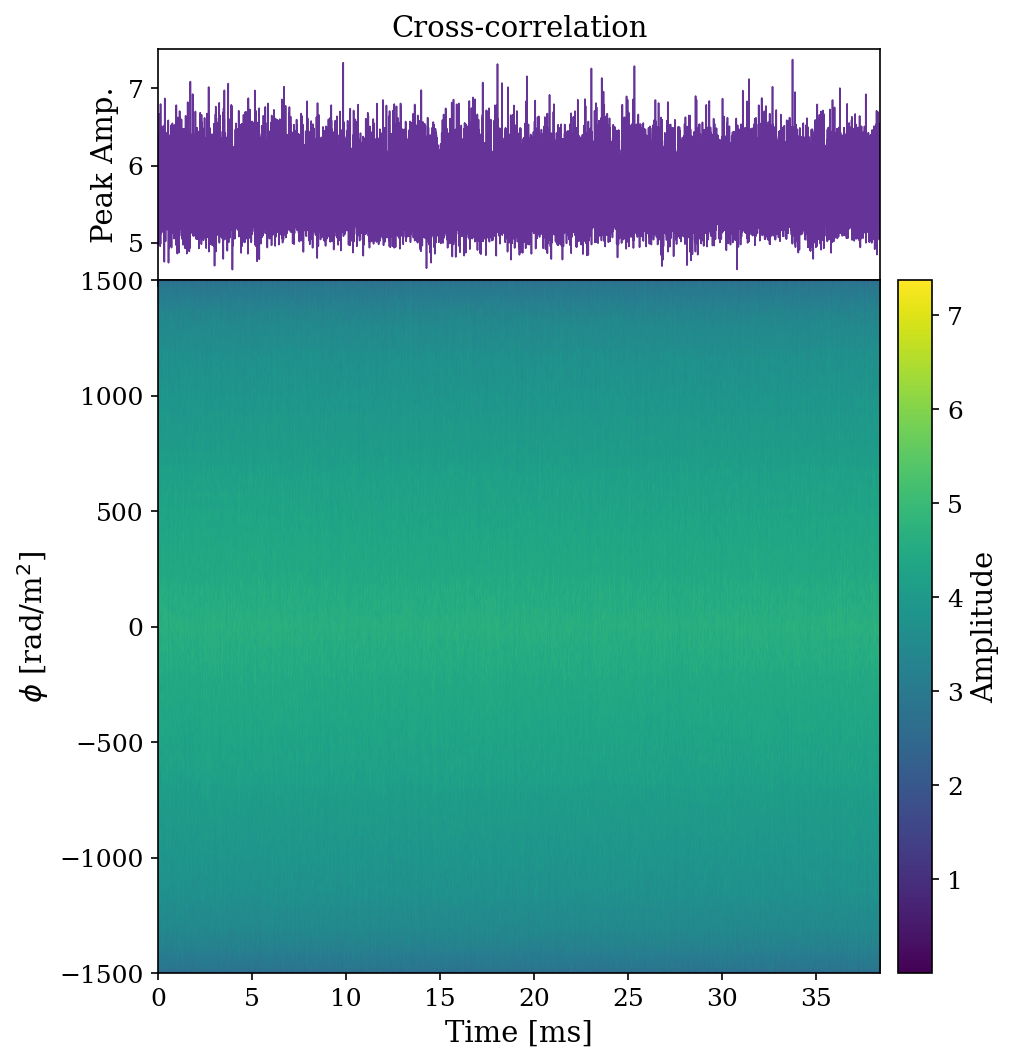

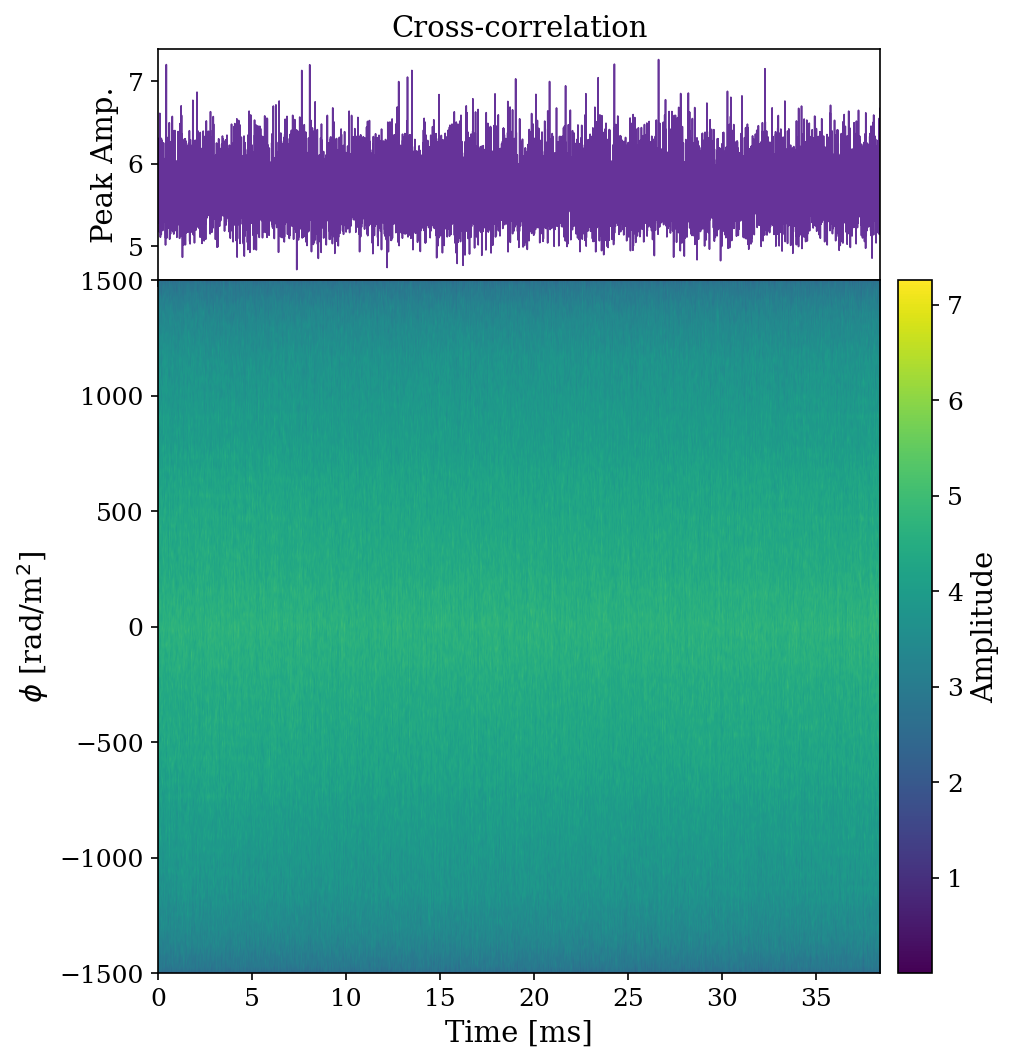

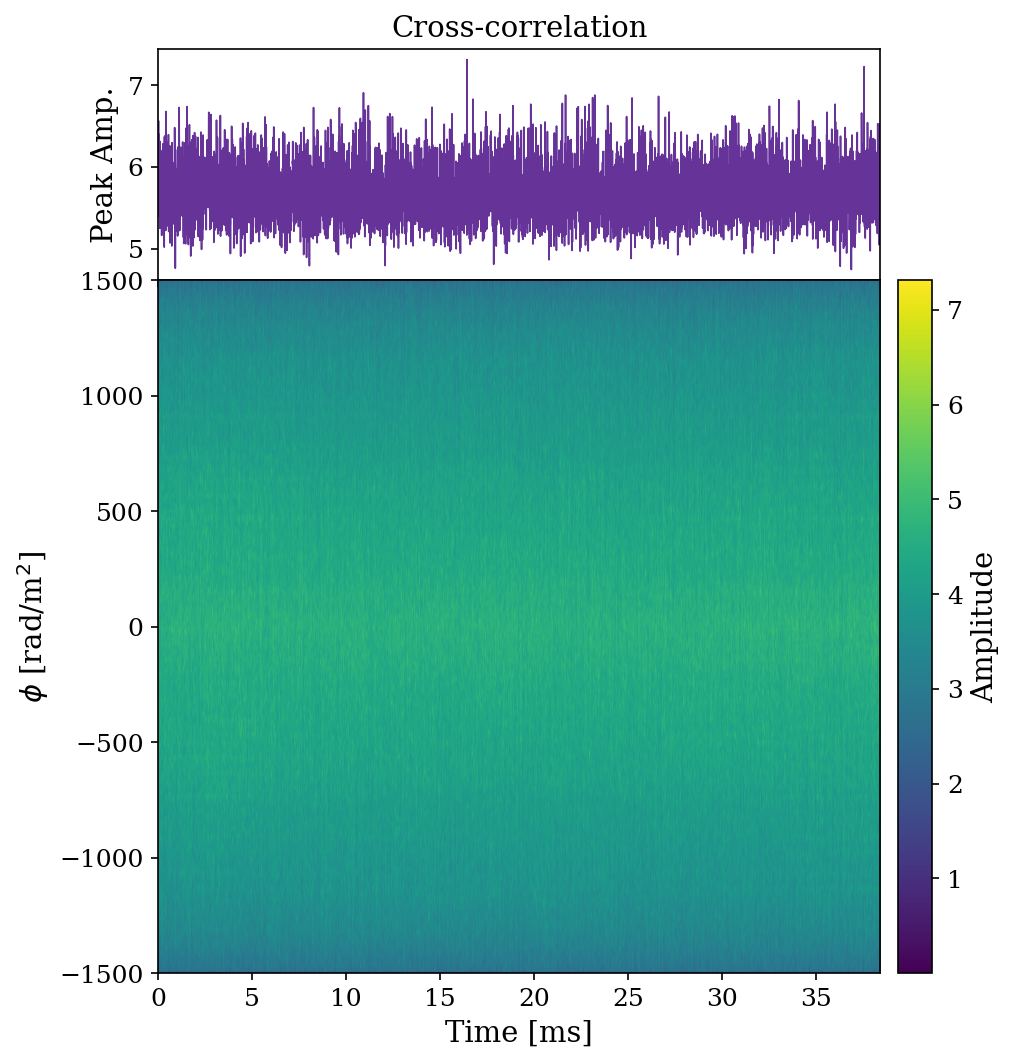

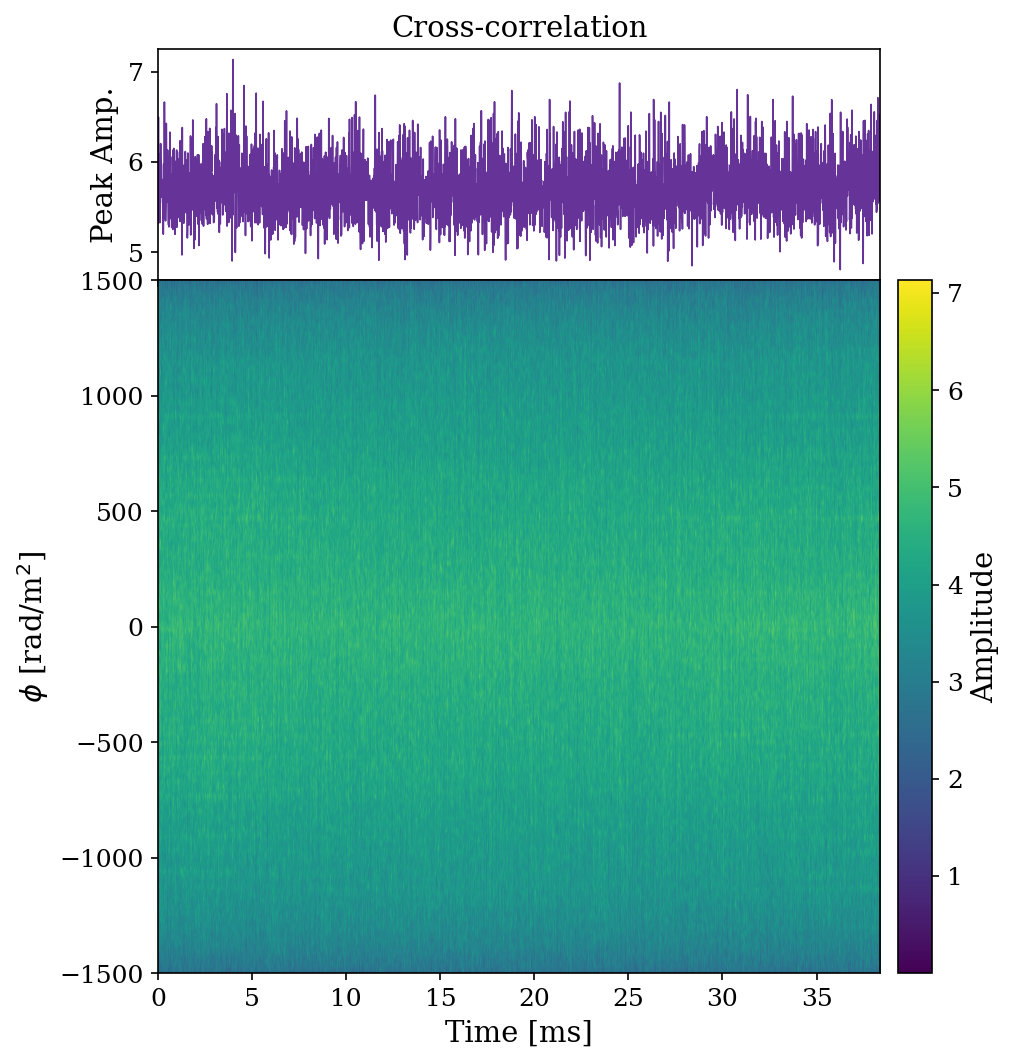

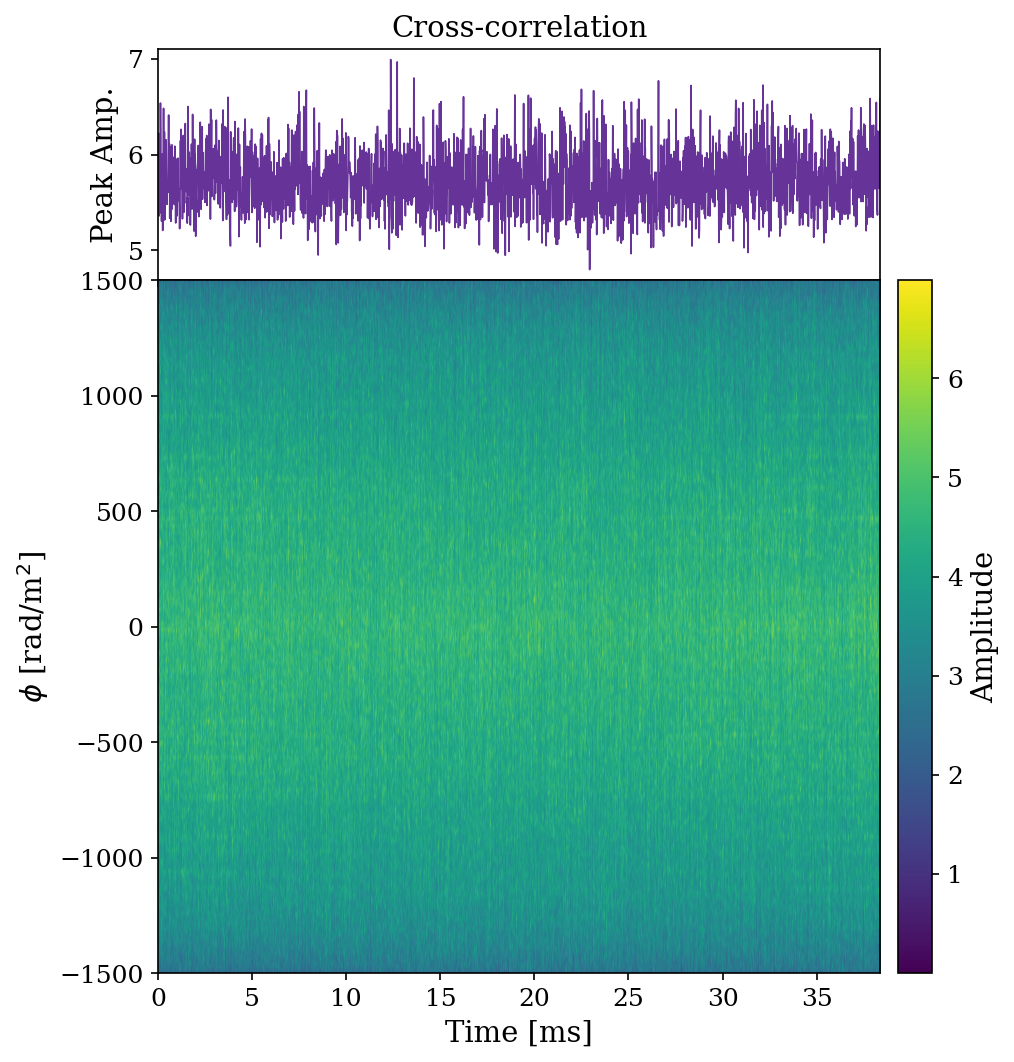

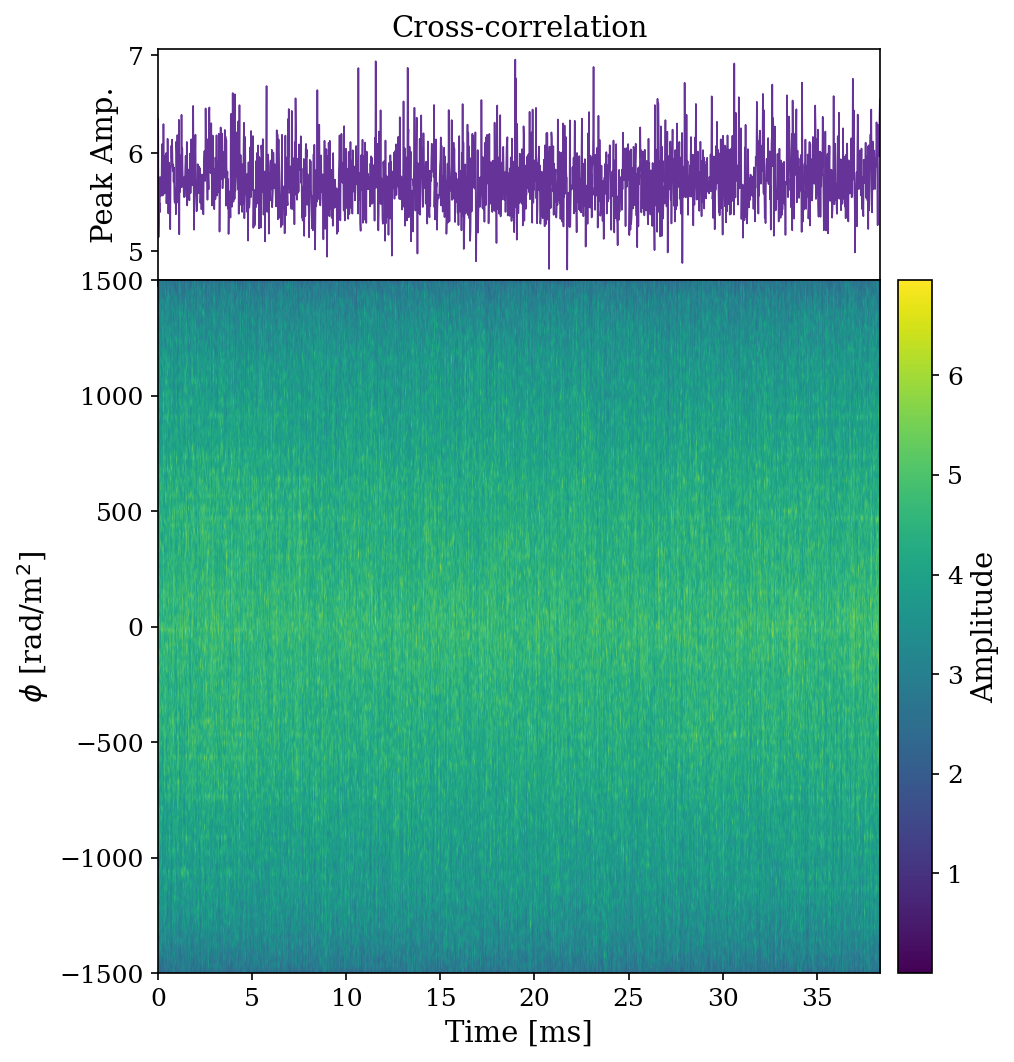

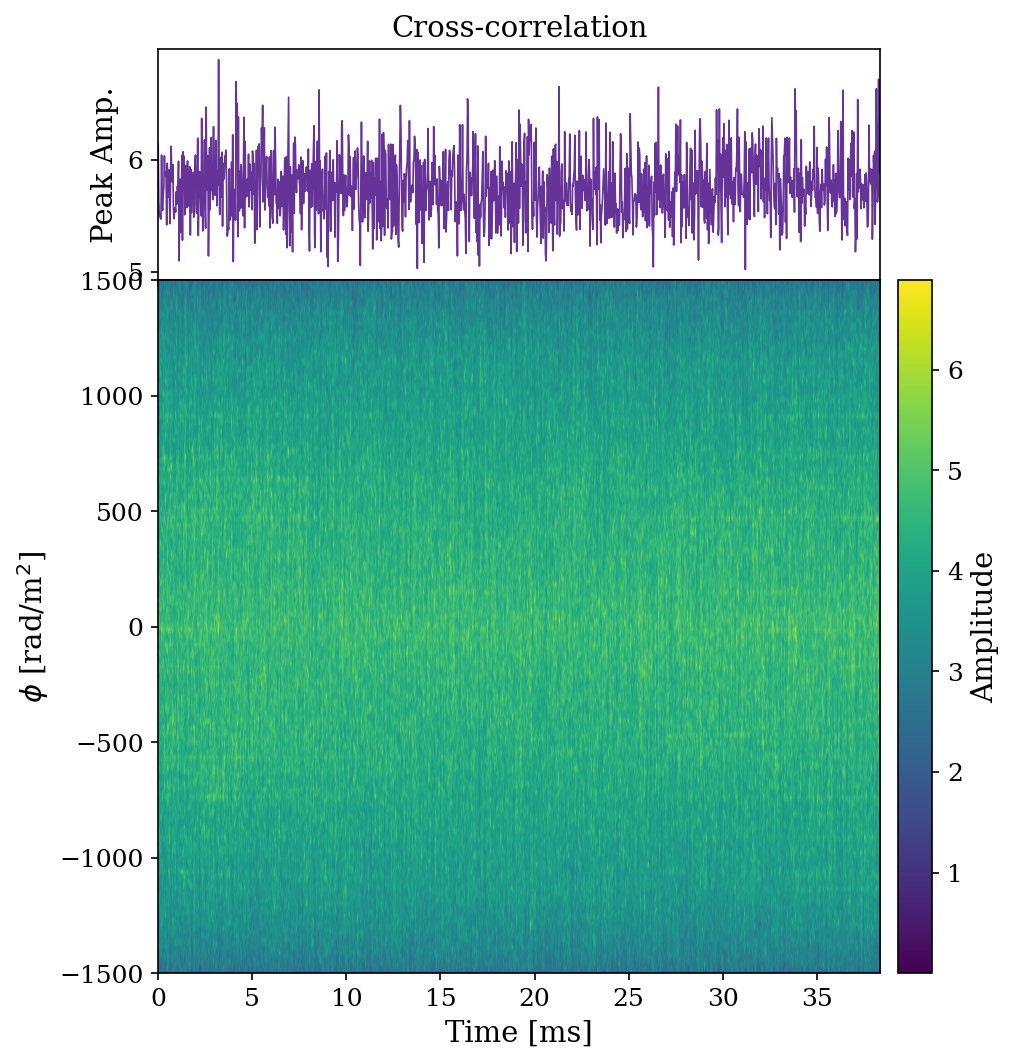

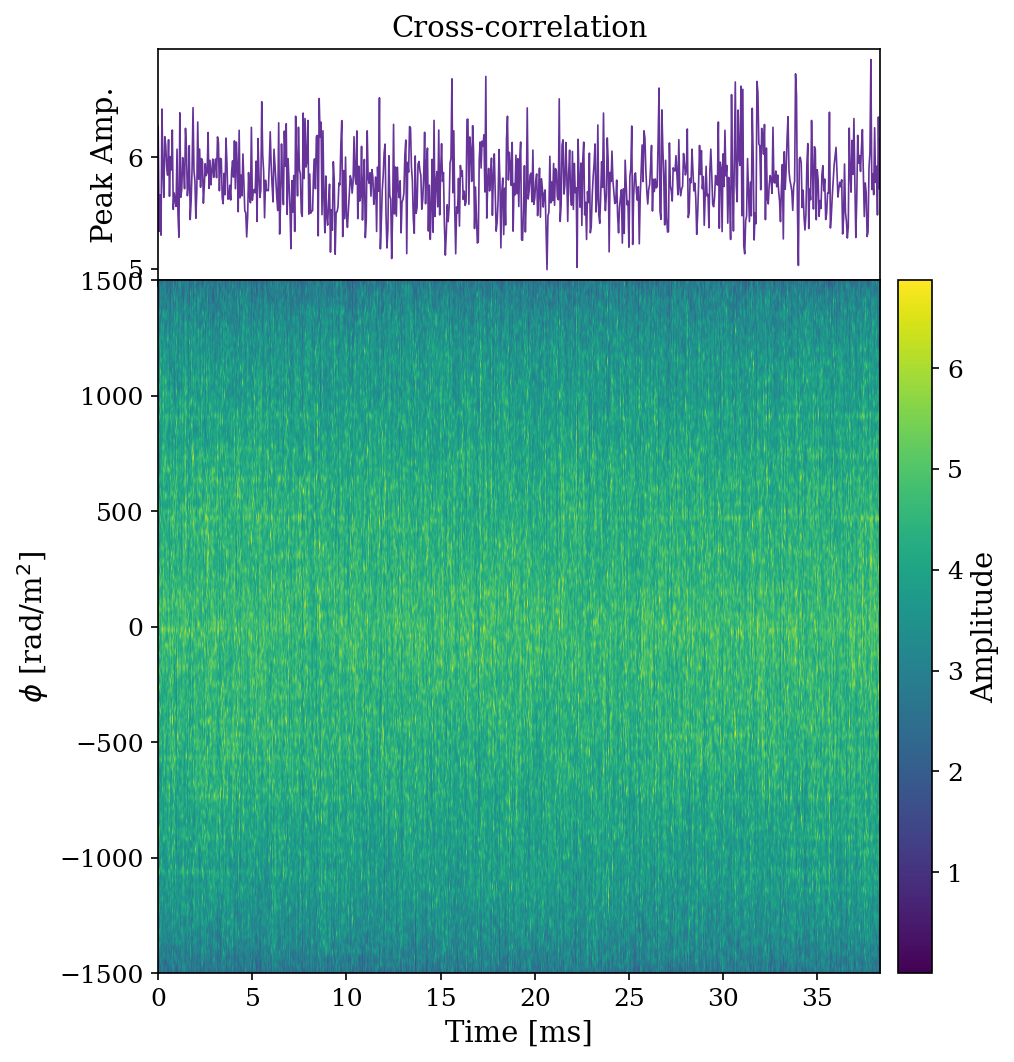

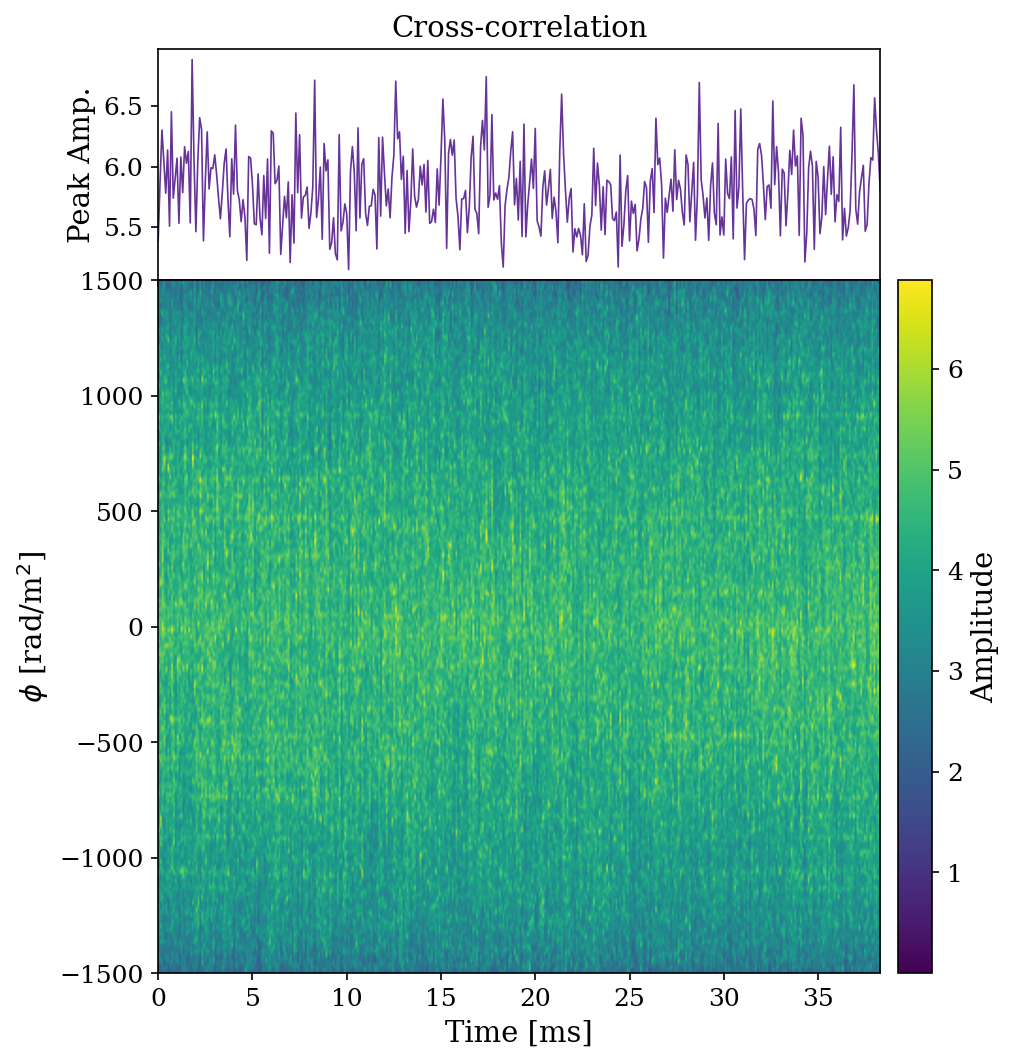

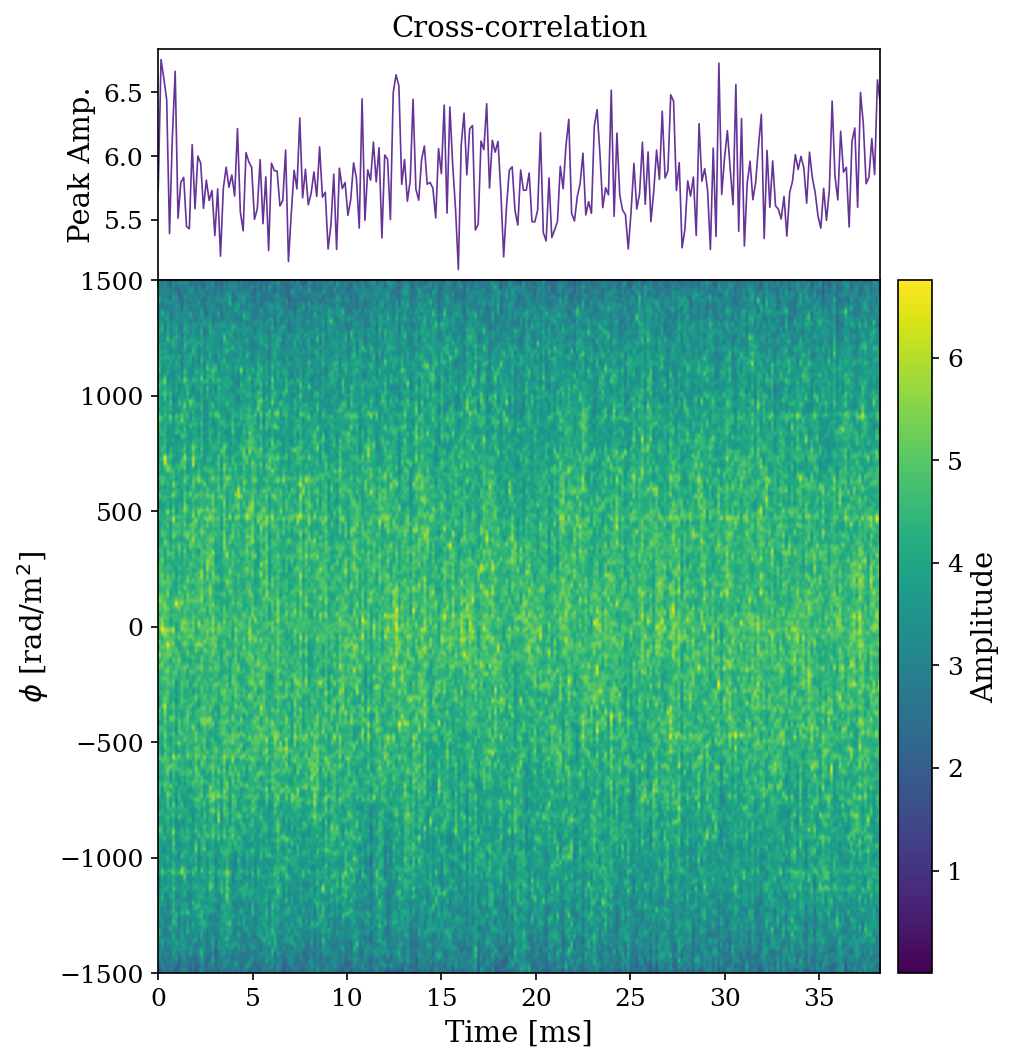

In [14]:
# Plot Cross-Correlations for each parameter
for i in range(NFILES):
    plot_2panels(cross_corr_arr[i], time_slice_arr[i], phi_lags[i], ax2_ylabel=r'$\phi$ [rad/m$^2$]', 
                 cbar_label='Amplitude', ax1_type='peak', suptitle='Cross-correlation', ylim=(-1500,1500),
                save_name=f'crosscorr_{PARAM}{param_list[i]}')

In [ ]:
# Plot cross-sorrelation slices

## ADD TO FUNCTION AND LOOP OVER NFILES
# plt.figure(figsize=(9, 6))
# plt.title('Cross-Correlation of FDF with RMSF')

# for i,t_slice in enumerate(cross_corr_arr):
#     # color = 'dodgerblue' if i in [ind1-1, ind1, ind1+1] else ('orange' if i in [ind2-1, ind2, ind2+1] else 'black')
#     color = 'k'
#     plt.plot(phi_lags, abs(t_slice), color=color, alpha=0.1, lw=0.7)

# # plt.plot(phi_lags, abs(cross_corr_arr[ind1]), color='dodgerblue', label=f'Burst 1 ({time_slice_arr[ind1]:.1f} {t_unit})')
# # plt.plot(phi_lags, abs(cross_corr_arr[ind2]), color='orange', label=f'Burst 2 ({time_slice_arr[ind2]:.1f} {t_unit})')
# plt.plot([], [], color='black', alpha=1, lw=1, label='Noise slices')

# # plt.axvline(x=RM_true[0], label='True RM 1', 
# #             color='dodgerblue', linestyle='--', alpha=0.6)
# # plt.axvline(x=RM_true[1], label='True RM 2', 
# #             color='orange', linestyle='--', alpha=0.6)

# plt.xlabel(r'$\phi$ [rad/m$^2$]')
# plt.ylabel('Amplitude')
# plt.xlim(-700, 700)

# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.show()

## Time curves

In [ ]:
# wall & cpu times vs param, grouped by block
plot_time_curves_by_block(param_list, dict_list, 'RM Step', 
                          fig_title=None, save_name='rmstep_timecurves',
                          plot_total=True, plot_wall=True, plot_ylog=True, convert_rm=True)

In [ ]:
# cpu efficiency vs param, grouped by code block 
plot_single_by_block(param_list, dict_list, 'RM Step', 
                     fig_title=None, save_name='rmstep_efficiency',
                     plot_total=True, plot_ylog=False, convert_rm=True)